In [8]:
import json
import torch 
from utils_milad import convert_to_onehot, get_gamma, convert_to_onehot, RandomFourierFeatures,set_seed
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
from scipy.stats import gaussian_kde
import scienceplots
plt.style.use(['science', 'no-latex'])

seed=0
set_seed(seed)

device = torch.device("cuda:6" if torch.cuda.is_available() else "cpu")

data = torch.load("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_llava_pope_train_features_normal_14_all_-1_milad.pth")
pos_data = torch.load("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_for_l2s_llava_pope_train_features_pos_answers_14_all_all_train_-1.pth")
neg_data = torch.load("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_for_l2s_llava_pope_train_features_neg_answers_14_all_all_train_-1.pth")
print(f"Data keys: {data.keys()}")
print(f"Positive data keys: {pos_data.keys()}")
print(f"Negative data keys: {neg_data.keys()}")

data_val = torch.load("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_llava_pope_train_features_normal_14_all_-1_val_milad.pth")
pos_data_val = torch.load("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_for_l2s_llava_pope_train_features_pos_answers_14_all_val_-1.pth")
neg_data_val = torch.load("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_for_l2s_llava_pope_train_features_neg_answers_14_all_val_-1.pth")
print(f"Validation data keys: {data_val.keys()}")
print(f"Validation positive data keys: {pos_data_val.keys()}")
print(f"Validation negative data keys: {neg_data_val.keys()}")



Data keys: dict_keys(['response', 'image', 'model_predictions', 'hidden_states'])
Positive data keys: dict_keys(['response', 'image', 'model_predictions', 'hidden_states'])
Negative data keys: dict_keys(['response', 'image', 'model_predictions', 'hidden_states'])
Validation data keys: dict_keys(['response', 'image', 'model_predictions', 'hidden_states'])
Validation positive data keys: dict_keys(['response', 'image', 'model_predictions', 'hidden_states'])
Validation negative data keys: dict_keys(['response', 'image', 'model_predictions', 'hidden_states'])


In [2]:
#checking the order of data is the same in pos_data and data

for i in range(len(data['image'])):
    if not pos_data["image"][i][0] == data["image"][i][0]:
        if not pos_data["response"][i][0] == data["response"][i][0]:
            print("pos data image does not match data image at index", i)
            
            
for i in range(len(data_val['image'])):
    if not pos_data_val["image"][i][0] == data_val["image"][i][0]:
        if not pos_data_val["response"][i][0] == data_val["response"][i][0]:
            print("pos data image does not match data image at index", i)


In [3]:
# add hallucination labels to data
data["hallucination_label"] = []
data["x_prompts"] = []
for i in range(len(data["model_predictions"])):
    if data["response"][i][0].lower() in data["model_predictions"][i][0][:20].lower():
        data["hallucination_label"].append(-1)
        data["x_prompts"].append(pos_data["hidden_states"][i]["language_model.model.layers.14"]["inputs"]["last_raw_input"])
    else:
        data["hallucination_label"].append(1)
        data["x_prompts"].append(pos_data["hidden_states"][i]["language_model.model.layers.14"]["inputs"]["last_raw_input"])


data_val["hallucination_label"] = []
data_val["x_prompts"] = []
for i in range(len(data_val["model_predictions"])):
    if data_val["response"][i][0].lower() in data_val["model_predictions"][i][0][:20].lower():
        data_val["hallucination_label"].append(-1)
        data_val["x_prompts"].append(pos_data_val["hidden_states"][i]["language_model.model.layers.14"]["inputs"]["last_raw_input"])
    else:
        data_val["hallucination_label"].append(1)
        data_val["x_prompts"].append(pos_data_val["hidden_states"][i]["language_model.model.layers.14"]["inputs"]["last_raw_input"])

In [4]:
print(np.unique(data["hallucination_label"], return_counts=True))

print(f"Number of non-hallucinations: {(np.array(data['hallucination_label'])  == -1).sum()}")
print(f"Number of hallucinations: {(np.array(data['hallucination_label']) == 1).sum()}")
print(f"Percentage of hallucinations: {(np.array(data['hallucination_label']) == 1).sum() / len(data['hallucination_label']) * 100:.2f}%")



print(np.unique(data_val["hallucination_label"], return_counts=True))
print(f"Number of non-hallucinations in validation set: {(np.array(data_val['hallucination_label'])  == -1).sum()}")
print(f"Number of hallucinations in validation set: {(np.array(data_val['hallucination_label']) == 1).sum()}")
print(f"Percentage of hallucinations in validation set: {(np.array(data_val['hallucination_label']) == 1).sum() / len(data_val['hallucination_label']) * 100:.2f}%")



(array([-1,  1]), array([5015, 1285]))
Number of non-hallucinations: 5015
Number of hallucinations: 1285
Percentage of hallucinations: 20.40%
(array([-1,  1]), array([715, 185]))
Number of non-hallucinations in validation set: 715
Number of hallucinations in validation set: 185
Percentage of hallucinations in validation set: 20.56%


In [5]:
x_prompts = torch.stack([data["x_prompts"][i] for i in range(len(data["x_prompts"]))])
x_prompts_val = torch.stack([data_val["x_prompts"][i] for i in range(len(data_val["x_prompts"]))])

x_prompt_mean = x_prompts.mean(dim=0)

x_prompts_hal = x_prompts[torch.tensor(data["hallucination_label"]) == 1].squeeze()
x_prompts_non_hal = x_prompts[torch.tensor(data["hallucination_label"]) == -1].squeeze()

x_prompts_hal_mean = x_prompts_hal.mean(dim=0)
x_prompts_non_hal_mean = x_prompts_non_hal.mean(dim=0)

x_prompt_mean_shift = x_prompts_non_hal_mean - x_prompts_hal_mean

n_train = x_prompts.shape[0]

In [6]:


# save the mean shift vector with a dictionary key "steering_vector" and repeat it n_train times to match the number of training samples
x_prompt_mean_shift_dict = {"steering_vector": x_prompt_mean_shift}
x_prompt_mean_shift_dict["steering_vector"] = x_prompt_mean_shift_dict["steering_vector"].unsqueeze(0).repeat(n_train, 1)
torch.save(x_prompt_mean_shift_dict, "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/shift_vectors/llava_14_average_all_pope_train_-1_mean_x_prompt.pth")

In [7]:
mean_shift_contrastive = torch.load("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/shift_vectors/llava_14_average_all_pope_train_-1.pth")
mean_shift_contrastive["steering_vector"].shape
mean_shift_non_contrastive = torch.load("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/shift_vectors/llava_14_average_all_pope_train_-1_mean_x_prompt.pth")
mean_shift_non_contrastive["steering_vector"].shape



torch.Size([6300, 4096])

In [8]:
mean_shift_non_contrastive["steering_vector"][0]

tensor([ 0.0627,  0.0209,  0.0429,  ..., -0.0393,  0.0112,  0.0359],
       dtype=torch.float16)

In [9]:
mean_shift_contrastive["steering_vector"][0]

tensor([[ 0.2120,  0.1136, -0.1462,  ..., -0.0373,  0.1077, -0.0828]])

In [63]:
x_prompt_mean_shift.shape

torch.Size([3584])

In [37]:
x_prompts.shape

torch.Size([6300, 1, 3584])

In [6]:
# x = x_prompts.squeeze().float().to(device)
# y = torch.tensor(data["hallucination_label"]).float().to(device)


# #zero hallucinated, one not hallucinated
# print(f"x.shape: {x.shape}, y.shape: {y.shape}")

# indices = np.arange(len(x))
# y_cpu = y.cpu().numpy()

# train_idx, test_idx = train_test_split(indices, test_size=0.001, random_state=seed, stratify=y_cpu,shuffle=True)


# # Convert indices to PyTorch tensors
# train_idx_t = torch.tensor(train_idx, device=device)
# test_idx_t = torch.tensor(test_idx, device=device)


# x_train, y_train = x[train_idx_t], y[train_idx_t]
# x_test, y_test   = x[test_idx_t], y[test_idx_t]

x_train = x_prompts.squeeze().float().to(device)
y_train = torch.tensor(data["hallucination_label"]).float().to(device)

x_test = x_prompts_val.squeeze().float().to(device)
y_test = torch.tensor(data_val["hallucination_label"]).float().to(device)

print(f"x_train.shape: {x_train.shape}, y_train.shape: {y_train.shape}")
print(f"x_test.shape: {x_test.shape}, y_test.shape: {y_test.shape}")

y_label = y_train
y_label_t = y_test


# y_train = convert_to_onehot(y_train)
# y_test = convert_to_onehot(y_test)


mean_x = x_train.mean(dim=0)
x_train_centered = x_train - mean_x
x_test_centered = x_test - mean_x
x_train_normalized = x_train_centered / x_train_centered.norm(dim=1,keepdim=True)
x_test_normalized = x_test_centered / x_test_centered.norm(dim=1, keepdim=True)

n, d = x_train.shape
print(f"n: {n}, d: {d}")



x_train.shape: torch.Size([6300, 4096]), y_train.shape: torch.Size([6300])
x_test.shape: torch.Size([900, 4096]), y_test.shape: torch.Size([900])
n: 6300, d: 4096


n_train: 6300, d: 4096
Train_Non-hallucinated: mu = 0.0094, sigma = 0.3830
Train_Hallucinated: mu = 0.2838, sigma = 0.2297
Test_Non-hallucinated: mu = 0.0274, sigma = 0.3719
Test_Hallucinated: mu = 0.2666, sigma = 0.2090


/tmp/ipykernel_2257509/2082542802.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


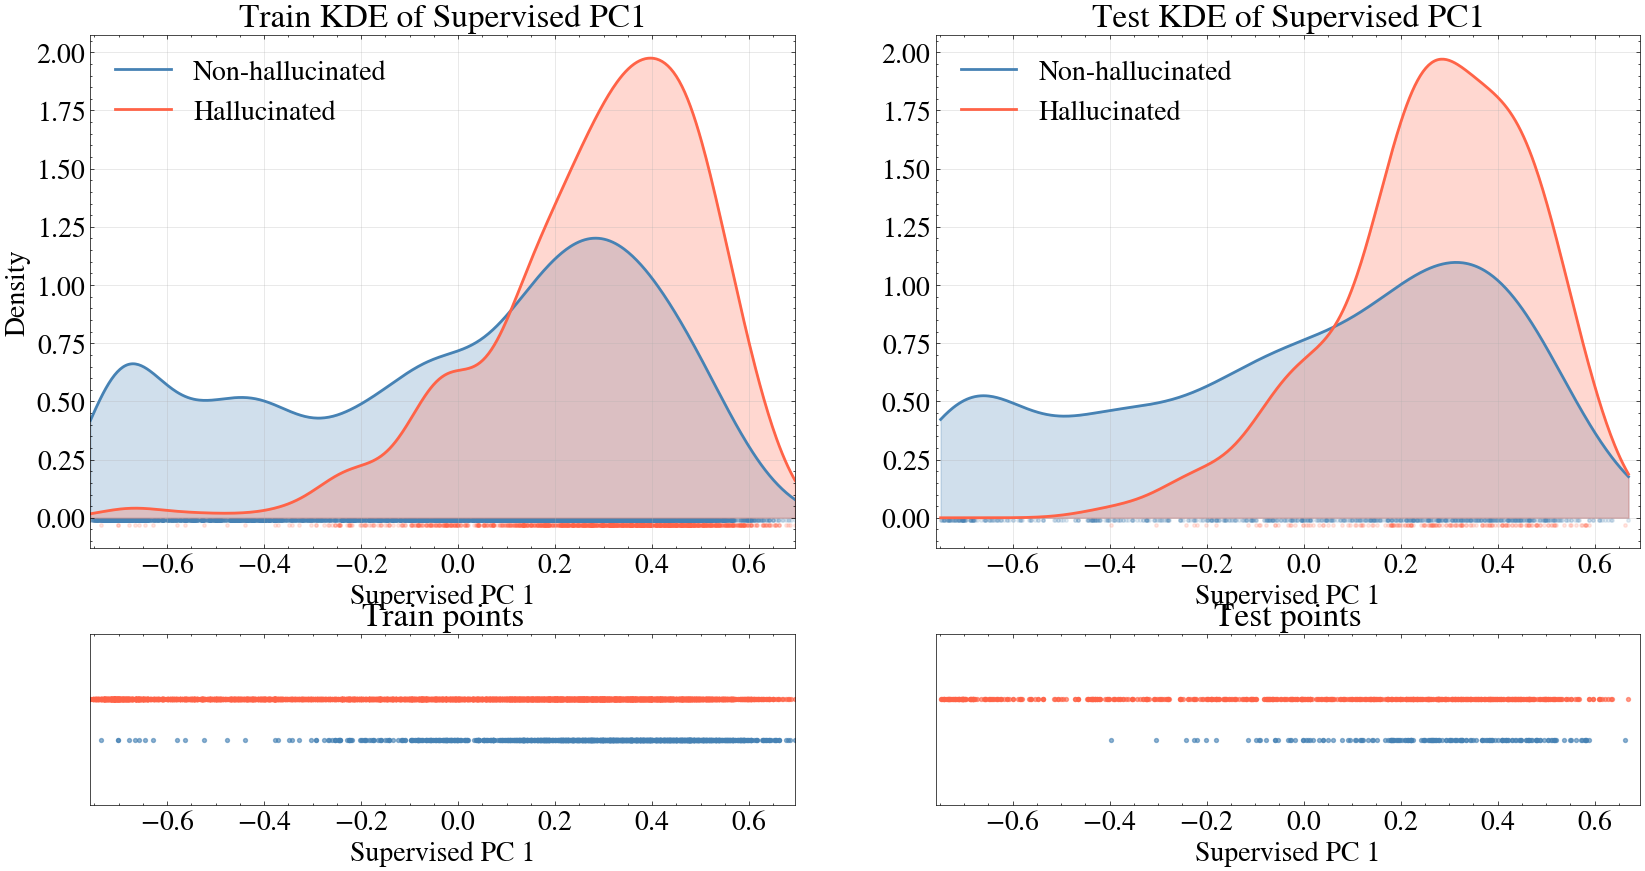

In [13]:
mean_x = x_train.mean(dim=0)
# Center the data
x_train_centered = x_train - mean_x
x_test_centered = x_test - mean_x
# Normalize the data to lie on the unit sphere
x_train_normalized = x_train_centered / x_train_centered.norm(dim=1,keepdim=True)
x_test_normalized = x_test_centered / x_test_centered.norm(dim=1, keepdim=True)


n, d = x_train.shape
print(f"n_train: {n}, d: {d}")


#Supervise PCA

# H = torch.eye(n,device=x_train.device)- (1/n)*torch.ones(n, n, device=x_train.device)
# # K_x = H @ (x_train_normalized @ x_train_normalized.T) @ H
# K_y = H @ y_train @ y_train.T @ H
# Q = x_train_normalized.T @ K_y @ x_train_normalized
# # Compute eigenvalues and eigenvectors
# eigenvalues, eigenvectors = torch.linalg.eigh(Q)
# U = eigenvectors[:, torch.argsort(eigenvalues, descending=True)]
# k=1
# u = U[:, 0:k]
# z_train = x_train_normalized @ u
# z_test = x_test_normalized @ u

H = torch.eye(n,device=x_train.device)- (1/n)*torch.ones(n, n, device=x_train.device)
y_train_col = y_train.view(-1, 1)
y_c = H @ y_train_col

v = x_train_normalized.T @ y_c
u = v / v.norm()
z_train = x_train_normalized @ u
z_test = x_test_normalized @ u

# prepare numpy arrays
z_train_np = z_train.detach().cpu().numpy().ravel()
z_test_np  = z_test.detach().cpu().numpy().ravel()
y_train_np = y_label.detach().cpu().numpy().ravel()
y_test_np  = y_label_t.detach().cpu().numpy().ravel()



xs_train = np.linspace(z_train_np.min() , z_train_np.max() , 500)
xs_test  = np.linspace(z_test_np.min() , z_test_np.max() , 500)
#change the font size of the plots to be larger for better visibility
plt.rcParams.update({'font.size': 20})
stats = {}
# build a 2x2 grid: top row = KDEs, bottom row = corresponding scatter strips
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[3, 1], hspace=0.25, wspace=0.2)

ax_kde_train = fig.add_subplot(gs[0, 0])
ax_kde_test  = fig.add_subplot(gs[0, 1], sharey=ax_kde_train)
ax_scatter_train = fig.add_subplot(gs[1, 0], sharex=ax_kde_train)
ax_scatter_test  = fig.add_subplot(gs[1, 1], sharex=ax_kde_test)

# Top row: KDEs (same as before)
for ax, zs, ys, xs, title in [
    (ax_kde_train, z_train_np, y_train_np, xs_train, "Train"),
    (ax_kde_test,  z_test_np,  y_test_np,  xs_test,  "Test")
]:
    for cls, name, color in [(-1, "Non-hallucinated", "steelblue"), (1, "Hallucinated", "tomato")]:
        mask = ys == cls
        if mask.sum() < 2:
            continue
        kde = gaussian_kde(zs[mask])
        pdf = kde(xs)
        pdf/=pdf.sum()
        mu = np.sum(xs*pdf)
        sigma = np.sqrt(np.sum((xs-mu)**2*pdf))
        stats[f"{title}_{name}"] = {"mu": mu, "sigma": sigma}
        print(f"{title}_{name}: mu = {mu:.4f}, sigma = {sigma:.4f}")
        ax.plot(xs, kde(xs), color=color, lw=2, label=name)
        ax.fill_between(xs, kde(xs), alpha=0.25, color=color)
        rug_y = -0.01 if cls == -1 else -0.03
        ax.scatter(zs[mask], np.full(mask.sum(), rug_y), color=color, alpha=0.15, s=6)

    ax.set_title(f"{title} KDE of Supervised PC1")
    ax.set_xlabel("Supervised PC 1")
    ax.grid(True, alpha=0.4)
    if ax is ax_kde_train:
        ax.set_ylabel("Density")
    ax.legend()

# Bottom row: horizontal scatter strips (one small row per train/test)
for ax, zs, ys, xs, title in [
    (ax_scatter_train, z_train_np, y_train_np, xs_train, "Train points"),
    (ax_scatter_test,  z_test_np,  y_test_np,  xs_test,  "Test points")
]:
    for cls, color, yval in [(-1, "tomato", 0.12), (1, "steelblue", -0.12)]:
        mask = ys == cls
        if mask.sum() == 0:
            continue
        y_vals = np.full(mask.sum(), yval)
        ax.scatter(zs[mask], y_vals, color=color, alpha=0.6, s=8)

    ax.set_yticks([])
    ax.set_title(title)
    ax.set_xlabel("Supervised PC 1")
    # keep a small vertical margin so points are visible
    ax.set_ylim(-0.5, 0.5)
    # align x-limits with the corresponding KDE x-range
    ax.set_xlim(min(xs_train.min(), xs_test.min()), max(xs_train.max(), xs_test.max()))


plt.tight_layout()
plt.show()


Train_Non-hallucinated: mu = -0.0126, sigma = 0.0311
Train_Hallucinated: mu = 0.0491, sigma = 0.0329
Test_Non-hallucinated: mu = -0.0059, sigma = 0.0347
Test_Hallucinated: mu = 0.0394, sigma = 0.0326


/tmp/ipykernel_2257509/1988319215.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


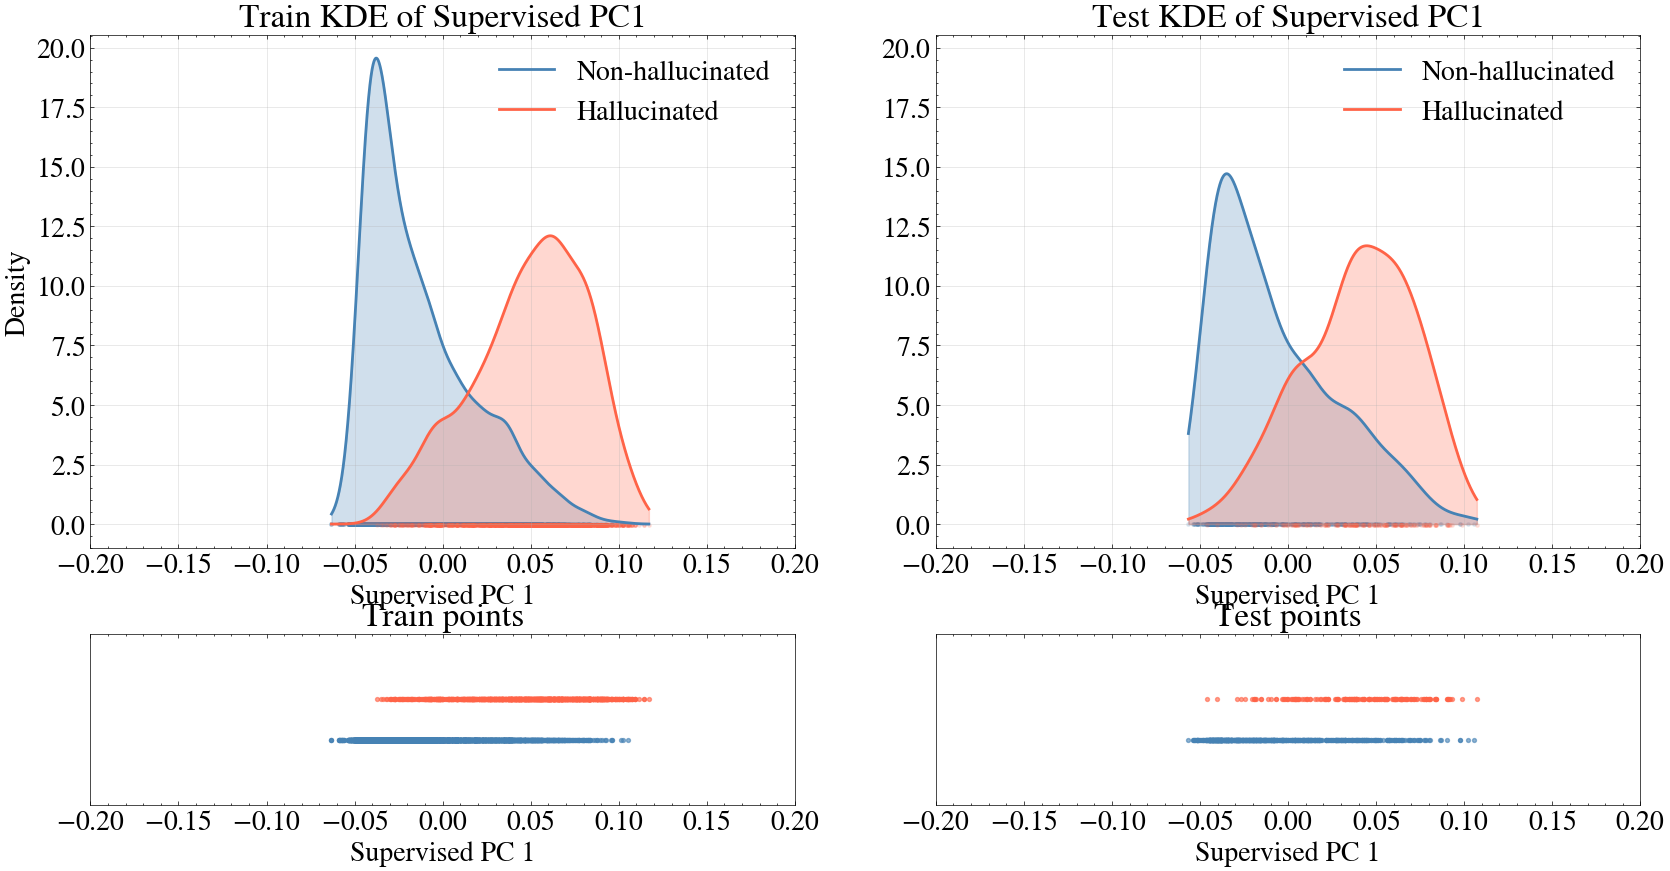

In [17]:
gamma = 1
lambda_reg = 5e-4
n = x_train_normalized.shape[0]
n_test = x_test_normalized.shape[0]

# 1. Enforce 2D column shape for labels and center them
y_train_col = y_train.view(-1, 1)
H = torch.eye(n, device=device) - (1/n) * torch.ones((n, n), device=device)
y_c = H @ y_train_col

# 2. Compute Exact RBF Kernels
# torch.cdist computes euclidean distance. Square it for the RBF formula.
dist_sq_train = torch.cdist(x_train_normalized, x_train_normalized, p=2)**2
K = torch.exp(-gamma * dist_sq_train)

dist_sq_test = torch.cdist(x_test_normalized, x_train_normalized, p=2)**2
K_test = torch.exp(-gamma * dist_sq_test)

# 3. Center the Kernel matrices
K_c = H @ K @ H

one_m_n = torch.ones((n_test, n), device=device) / n
K_test_c = (K_test - one_m_n @ K) @ H

# 4. Construct the regularized covariance
Sigma = ((1 - lambda_reg) / n) * K_c + lambda_reg * torch.eye(n, device=device)

# 5. Solve for the dual coefficients alpha (Sigma * alpha = y_c)
alpha = torch.linalg.solve(Sigma, y_c)

# 6. Normalize alpha so the implied projection vector V1 has unit length
# ||V1||^2 = alpha^T * K_c * alpha
norm_sq = alpha.T @ K_c @ alpha
alpha_normalized = alpha / torch.sqrt(norm_sq)

# 7. Project your data using the exact kernel
z_train_k = K_c @ alpha_normalized
z_test_k = K_test_c @ alpha_normalized



z_train_k_np = z_train_k.detach().cpu().numpy().ravel()
z_test_k_np  = z_test_k.detach().cpu().numpy().ravel()
y_train_k_np = y_label.detach().cpu().numpy().ravel()
y_test_k_np  = y_label_t.detach().cpu().numpy().ravel()


xs_train_k = np.linspace(z_train_k_np.min() , z_train_k_np.max() ,5000)
xs_test_k  = np.linspace(z_test_k_np.min() , z_test_k_np.max() , 5000)

# build a 2x2 grid: top row = KDEs, bottom row = corresponding scatter strips
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[3, 1], hspace=0.25, wspace=0.2)

ax_kde_train = fig.add_subplot(gs[0, 0])
ax_kde_test  = fig.add_subplot(gs[0, 1], sharey=ax_kde_train)
ax_scatter_train = fig.add_subplot(gs[1, 0], sharex=ax_kde_train)
ax_scatter_test  = fig.add_subplot(gs[1, 1], sharex=ax_kde_test)

stats = {}
# Top row: KDEs (same as before)
for ax, zs, ys, xs, title in [
    (ax_kde_train, z_train_k_np, y_train_k_np, xs_train_k, "Train"),
    (ax_kde_test,  z_test_k_np,  y_test_k_np,  xs_test_k,  "Test")
]:
    for cls, name, color in [(-1, "Non-hallucinated", "steelblue"), (1, "Hallucinated", "tomato")]:
        mask = ys == cls
        if mask.sum() < 2:
            continue
        kde = gaussian_kde(zs[mask])
        pdf = kde(xs)
        pdf/=pdf.sum()
        mu = np.sum(xs*pdf)
        sigma = np.sqrt(np.sum((xs-mu)**2*pdf))
        stats[f"{title}_{name}"] = {"mu": mu, "sigma": sigma}
        print(f"{title}_{name}: mu = {mu:.4f}, sigma = {sigma:.4f}")
        ax.plot(xs, kde(xs), color=color, lw=2, label=name)
        ax.fill_between(xs, kde(xs), alpha=0.25, color=color)
        rug_y = -0.01 if cls == -1 else -0.03
        ax.scatter(zs[mask], np.full(mask.sum(), rug_y), color=color, alpha=0.15, s=6)

    ax.set_title(f"{title} KDE of Supervised PC1")
    ax.set_xlabel("Supervised PC 1")
    ax.grid(True, alpha=0.4)
    if ax is ax_kde_train:
        ax.set_ylabel("Density")
    ax.legend()


# Bottom row: horizontal scatter strips (one small row per train/test)
for ax, zs, ys, title in [
    (ax_scatter_train, z_train_k_np, y_train_k_np,"Train points"),
    (ax_scatter_test,  z_test_k_np,  y_test_k_np,  "Test points")
]:
    for cls, color, yval in [(+1, "tomato", 0.12), (-1, "steelblue", -0.12)]:
        mask = ys == cls
        if mask.sum() == 0:
            continue
        y_vals = np.full(mask.sum(), yval)
        ax.scatter(zs[mask], y_vals, color=color, alpha=0.6, s=8)

    ax.set_yticks([])
    ax.set_title(title)
    ax.set_xlabel("Supervised PC 1")
    # keep a small vertical margin so points are visible
    ax.set_ylim(-0.5, 0.5)
    # align x-limits with the corresponding KDE x-range 
    if title == "Train points":
        ax.set_xlim(xs_train_k.min(), xs_train_k.max())
    else:
        ax.set_xlim(xs_test_k.min(), xs_test_k.max()) 
    ax.set_xlim(-0.2, 0.2)



plt.tight_layout()
plt.show()

In [12]:
import torch
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import scienceplots
# use science style plt
plt.style.use(['science', 'no-latex'])

def project_linear_spca(x_train, y_train, x_test):
    """
    Executes exact 1D Linear Supervised PCA.
    
    Inputs:
    - x_train, x_test: Normalized feature tensors (n_samples, d_features)
    - y_train: 1D or 2D binary label tensor {-1, 1}
    
    Returns:
    - z_train, z_test: 1D numpy arrays of the projected data
    """
    n = x_train.shape[0]
    device = x_train.device
    
    # Strictly enforce 2D column shape for labels
    y_train_col = y_train.view(-1, 1).float()
    
    # Center the labels
    H = torch.eye(n, device=device) - (1/n) * torch.ones(n, n, device=device)
    y_c = H @ y_train_col
    
    # Compute projection axis directly
    v = x_train.T @ y_c
    u = v / torch.linalg.norm(v)
    
    # Project and flatten to numpy arrays for evaluation
    z_train = (x_train @ u).detach().cpu().numpy().ravel()
    z_test = (x_test @ u).detach().cpu().numpy().ravel()
    
    return z_train, z_test


def project_kernel_spca(x_train, y_train, x_test, gamma=0.1, lambda_reg=1e-4):
    """
    Executes exact 1D Kernel Supervised PCA via Dual KRR formulation.
    
    Inputs:
    - x_train, x_test: Normalized feature tensors
    - y_train: Binary label tensor {-1, 1}
    - gamma: RBF kernel bandwidth
    - lambda_reg: Regularization parameter
    
    Returns:
    - z_train_k, z_test_k: 1D numpy arrays of the projected data
    """
    n = x_train.shape[0]
    n_test = x_test.shape[0]
    device = x_train.device
    
    # Strictly enforce 2D column shape for labels
    y_train_col = y_train.view(-1, 1).float()
    
    # Center the labels
    H = torch.eye(n, device=device) - (1/n) * torch.ones((n, n), device=device)
    y_c = H @ y_train_col
    
    # Exact RBF Kernels
    dist_sq_train = torch.cdist(x_train, x_train, p=2)**2
    K = torch.exp(-gamma * dist_sq_train)
    
    dist_sq_test = torch.cdist(x_test, x_train, p=2)**2
    K_test = torch.exp(-gamma * dist_sq_test)
    
    # Center Kernel matrices
    K_c = H @ K @ H
    one_m_n = torch.ones((n_test, n), device=device) / n
    K_test_c = (K_test - one_m_n @ K) @ H
    
    
    # Solve for dual coefficients
    Sigma = ((1 - lambda_reg) / n) * K_c + lambda_reg * torch.eye(n, device=device)
    alpha = torch.linalg.solve(Sigma, y_c)
    
    # Normalize
    norm_sq = alpha.T @ K_c @ alpha
    alpha_normalized = alpha / torch.sqrt(norm_sq)
    
    # Project and flatten
    z_train_k = (K_c @ alpha_normalized).detach().cpu().numpy().ravel()
    z_test_k = (K_test_c @ alpha_normalized).detach().cpu().numpy().ravel()
    
    return z_train_k, z_test_k


def evaluate_spca_roc(y_test_true, z_test_linear, z_test_kernel):
    """
    Calculates AUC and plots ROC for Linear vs Kernel SPCA projections.
    
    Inputs:
    - y_test_true: Tensor or array of true test labels {-1, 1}
    - z_test_linear: 1D numpy array of linear projections
    - z_test_kernel: 1D numpy array of kernel projections
    """
    # Force numpy format and convert {-1, 1} to {0, 1} for sklearn
    if torch.is_tensor(y_test_true):
        y_test_true = y_test_true.detach().cpu().numpy().ravel()
    y_test_binary = (y_test_true == 1).astype(int)

    # Calculate ROC metrics
    fpr_lin, tpr_lin, _ = roc_curve(y_test_binary, z_test_linear)
    auc_lin = auc(fpr_lin, tpr_lin)
    
    fpr_ker, tpr_ker, _ = roc_curve(y_test_binary, z_test_kernel)
    auc_ker = auc(fpr_ker, tpr_ker)

    # Plotting
    plt.figure(figsize=(5, 4))
    plt.plot(fpr_lin, tpr_lin, color='steelblue', lw=2, label=f'Linear SPCA (AUC = {auc_lin:.3f})')
    plt.plot(fpr_ker, tpr_ker, color='tomato', lw=2, label=f'Kernel SPCA (AUC = {auc_ker:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('ROC Curve: Linear vs. Kernel Supervised PCA')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

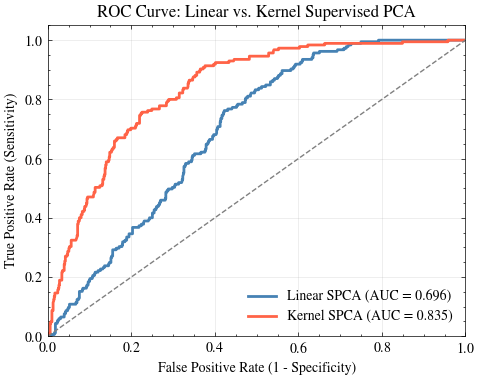

In [13]:
# 1. Generate Projections
z_train_lin, z_test_lin = project_linear_spca(x_train_normalized, y_train, x_test_normalized)
z_train_ker, z_test_ker = project_kernel_spca(x_train_normalized, y_train, x_test_normalized, gamma=1, lambda_reg=5e-4)

# 2. Evaluate the Brutal Truth
evaluate_spca_roc(y_label_t, z_test_lin, z_test_ker)

In [14]:
#save the K, alpha_normalized, and mean_x for later use in a dictionary
spca_model_llava_14_all = {
    "K": K.detach().cpu(),
    "alpha_normalized": alpha_normalized.detach().cpu(),
    "mean_x": mean_x.detach().cpu(),
    "x_train_normalized": x_train_normalized.detach().cpu(),
}

torch.save(spca_model_llava_14_all, "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/spca_models/spca_model_llava_14_all_pope_train_-1.pth")

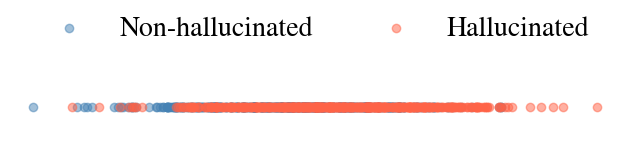

In [36]:

# Generate two overlapping 1D distributions
points_class0 = np.random.normal(loc=0.0, scale=1.0, size=500)
points_class1 = np.random.normal(loc=0.5, scale=1.0, size=500)

# Small vertical jitter only for visualization
y0 = np.random.normal(loc=0.0, scale=0.00, size=500)
y1 = np.random.normal(loc=0.0, scale=0.00, size=500)

plt.figure(figsize=(8, 1))

plt.scatter(points_class0, y0, color='steelblue', alpha=0.5, label='Non-hallucinated')
plt.scatter(points_class1, y1, color='tomato', alpha=0.5, label='Hallucinated')

# plt.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
# plt.axhline(0.15, color='gray', linewidth=0.8, alpha=0.5)

# plt.xlabel('Feature')
plt.yticks([])
plt.xticks([])
plt.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False
)
ax = plt.gca()

for spine in ax.spines.values():
    spine.set_visible(False)
# plt.grid(False)
# plt.title('Overlapping One-Dimensional Points')
plt.show()



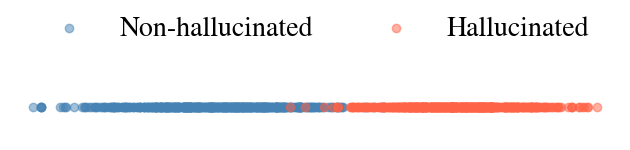

In [48]:

# Generate two overlapping 1D distributions
points_class0 = np.random.normal(loc=0.-1, scale=.5, size=500)
points_class1 = np.random.normal(loc=1, scale=.45, size=500)

# Small vertical jitter only for visualization
y0 = np.random.normal(loc=0.0, scale=0.00, size=500)
y1 = np.random.normal(loc=0.0, scale=0.00, size=500)

plt.figure(figsize=(8, 1))

plt.scatter(points_class0, y0, color='steelblue', alpha=0.5, label='Non-hallucinated')
plt.scatter(points_class1, y1, color='tomato', alpha=0.5, label='Hallucinated')

# plt.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
# plt.axhline(0.15, color='gray', linewidth=0.8, alpha=0.5)

# plt.xlabel('Feature')
plt.yticks([])
plt.xticks([])
plt.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False
)
ax = plt.gca()

for spine in ax.spines.values():
    spine.set_visible(False)
# plt.grid(False)
# plt.title('Overlapping One-Dimensional Points')
plt.show()


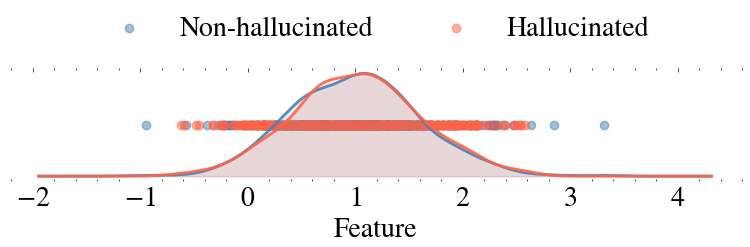

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

np.random.seed(42)

# More separable 1D distributions
points_class0 = np.random.normal(loc=1.0, scale=0.6, size=500)
points_class1 = np.random.normal(loc=1.0, scale=0.6, size=500)

# Small vertical jitter only for visualization
y0 = np.random.normal(loc=0.0, scale=0.0, size=500)
y1 = np.random.normal(loc=0.0, scale=0.0, size=500)

fig, ax = plt.subplots(figsize=(8, 3))

# Scatter plot
ax.scatter(points_class0, y0, color='steelblue', alpha=0.5, label='Non-hallucinated')
ax.scatter(points_class1, y1, color='tomato', alpha=0.5, label='Hallucinated')

ax.set_xlabel('Feature')
ax.set_yticks([])

# Remove box
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False)

# KDE on a second y-axis
ax2 = ax.twinx()

x_min = min(points_class0.min(), points_class1.min()) - 1
x_max = max(points_class0.max(), points_class1.max()) + 1
x_vals = np.linspace(x_min, x_max, 500)

kde0 = gaussian_kde(points_class0)
kde1 = gaussian_kde(points_class1)

density0 = kde0(x_vals)
density1 = kde1(x_vals)

ax2.plot(x_vals, density0, color='steelblue', linewidth=2, alpha=0.9)
ax2.plot(x_vals, density1, color='tomato', linewidth=2, alpha=0.9)

# Optional fill under KDE curves
ax2.fill_between(x_vals, 0, density0, color='steelblue', alpha=0.15)
ax2.fill_between(x_vals, 0, density1, color='tomato', alpha=0.15)

# Hide second y-axis
ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.tick_params(right=False)

# Legend on top
ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

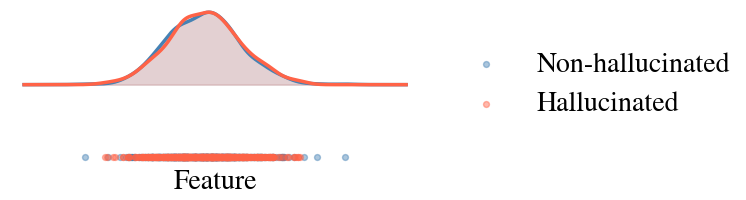

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

np.random.seed(42)

# More separable 1D distributions
points_class0 = np.random.normal(loc=1.0, scale=0.6, size=500)
points_class1 = np.random.normal(loc=1.0, scale=0.6, size=500)

# Jittered points near the bottom
y0 = np.random.normal(loc=0.00, scale=0.0, size=500)
y1 = np.random.normal(loc=0.0, scale=0.0, size=500)

fig, ax = plt.subplots(figsize=(8, 2.5))

# Scatter points
ax.scatter(
    points_class0, y0,
    color='steelblue',
    alpha=0.45,
    s=18,
    label='Non-hallucinated'
)

ax.scatter(
    points_class1, y1,
    color='tomato',
    alpha=0.45,
    s=18,
    label='Hallucinated'
)

# KDE x-grid
x_min = min(points_class0.min(), points_class1.min()) - 1
x_max = max(points_class0.max(), points_class1.max()) + 1
x_vals = np.linspace(x_min, x_max, 500)

# KDE
kde0 = gaussian_kde(points_class0)
kde1 = gaussian_kde(points_class1)

density0 = kde0(x_vals)
density1 = kde1(x_vals)

# Normalize KDEs and move them above the points
density_scale = 0.45
density_offset = 0.45

density0_scaled = density0 / density0.max() * density_scale + density_offset
density1_scaled = density1 / density1.max() * density_scale + density_offset

# Plot KDEs above point cloud
ax.plot(
    x_vals,
    density0_scaled,
    color='steelblue',
    linewidth=2.5,
    # label='KDE: Non-hallucinated'
)

ax.plot(
    x_vals,
    density1_scaled,
    color='tomato',
    linewidth=2.5,
    # label='KDE: Hallucinated'
)

# Fill under KDEs
ax.fill_between(
    x_vals,
    density_offset,
    density0_scaled,
    color='steelblue',
    alpha=0.18
)

ax.fill_between(
    x_vals,
    density_offset,
    density1_scaled,
    color='tomato',
    alpha=0.18
)

# # Optional separator between points and KDE
# ax.axhline(
#     density_offset,
#     color='gray',
#     linewidth=0.2,
#     alpha=0.35
# )

# Labels
ax.set_xlabel('Feature')
ax.set_yticks([])
ax.set_xticks([])
# Remove figure box
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(left=False, bottom=False)

# Move legend outside the plot
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

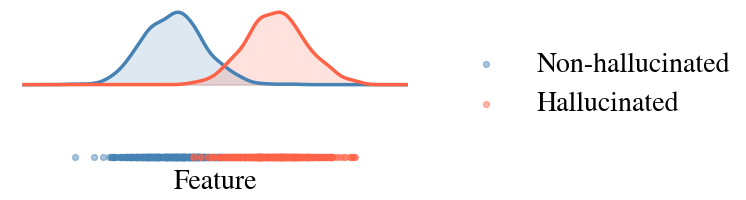

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

np.random.seed(42)

# More separable 1D distributions
points_class0 = np.random.normal(loc=-1.0, scale=0.6, size=500)
points_class1 = np.random.normal(loc=1.0, scale=0.6, size=500)

# Jittered points near the bottom
y0 = np.random.normal(loc=0.00, scale=0.0, size=500)
y1 = np.random.normal(loc=0.0, scale=0.0, size=500)

fig, ax = plt.subplots(figsize=(8, 2.5))

# Scatter points
ax.scatter(
    points_class0, y0,
    color='steelblue',
    alpha=0.45,
    s=18,
    label='Non-hallucinated'
)

ax.scatter(
    points_class1, y1,
    color='tomato',
    alpha=0.45,
    s=18,
    label='Hallucinated'
)

# KDE x-grid
x_min = min(points_class0.min(), points_class1.min()) - 1
x_max = max(points_class0.max(), points_class1.max()) + 1
x_vals = np.linspace(x_min, x_max, 500)

# KDE
kde0 = gaussian_kde(points_class0)
kde1 = gaussian_kde(points_class1)

density0 = kde0(x_vals)
density1 = kde1(x_vals)

# Normalize KDEs and move them above the points
density_scale = 0.45
density_offset = 0.45

density0_scaled = density0 / density0.max() * density_scale + density_offset
density1_scaled = density1 / density1.max() * density_scale + density_offset

# Plot KDEs above point cloud
ax.plot(
    x_vals,
    density0_scaled,
    color='steelblue',
    linewidth=2.5,
    # label='KDE: Non-hallucinated'
)

ax.plot(
    x_vals,
    density1_scaled,
    color='tomato',
    linewidth=2.5,
    # label='KDE: Hallucinated'
)

# Fill under KDEs
ax.fill_between(
    x_vals,
    density_offset,
    density0_scaled,
    color='steelblue',
    alpha=0.18
)

ax.fill_between(
    x_vals,
    density_offset,
    density1_scaled,
    color='tomato',
    alpha=0.18
)

# # Optional separator between points and KDE
# ax.axhline(
#     density_offset,
#     color='gray',
#     linewidth=0.2,
#     alpha=0.35
# )

# Labels
ax.set_xlabel('Feature')
ax.set_yticks([])
ax.set_xticks([])
# Remove figure box
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(left=False, bottom=False)

# Move legend outside the plot
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()